# **<font color="red">5 Keys Points for Ridge Regression Understanding</font>**

## **<font color="green">1. How are coefficients affected?</font>**
- The alpha is inversily propotional to the coeffients. As the value of alpha increases the value of coefficient decreases.
- If the vlaue of alpha is too high then the value of coefficient will be close to zero but never be zero.

In [1]:
from sklearn.datasets import load_diabetes
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

data = load_diabetes()

X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, test_size=0.2, random_state=2)

df = pd.DataFrame(data.data, columns=data.feature_names)
df['Target'] = data.target
print(df.shape)
df.head()


(442, 11)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,Target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [2]:
coefs = []
r2_scores = []
alphas = [0, 10, 100, 1000]
colors = ['red', 'green', 'pink', 'skyblue']

for alpha in alphas:
    reg = Ridge(alpha=alpha)
    reg.fit(X_train, y_train)
    coefs.append(reg.coef_.tolist())
    y_pred = reg.predict(X_test)
    r2_scores.append(r2_score(y_test, y_pred))

print("Weights: ", coefs, "\n")
print("Scores: ", r2_scores)


Weights:  [[-9.158653181170363, -205.45432163452114, 516.6937445408271, 340.61999904554847, -895.5520019034768, 561.2206790413021, 153.89310953635996, 126.731396878462, 861.1270015229967, 52.42112237904704], [21.174024430657028, 1.6598369427666693, 63.65982584237654, 48.49285812895809, 18.42151032381465, 12.875465784744849, -38.915434727002285, 38.842475443812965, 61.61230248383494, 35.505383019498474], [2.858979751926675, 0.6294525865756895, 7.540605233970548, 5.849949459815251, 2.710878806908419, 2.1421346679368316, -4.834047020128568, 5.108223464961738, 7.4484511161018006, 4.576129087936827], [0.2957255635919191, 0.0692902920579852, 0.7690038138539067, 0.5978244450322281, 0.2828995164297864, 0.22593550890314165, -0.4956069094337926, 0.5270313443400051, 0.7614958982209438, 0.47102907018042245]] 

Scores:  [0.43993386615689667, 0.15214327672566985, 0.010378115936827137, -0.010136670498663625]


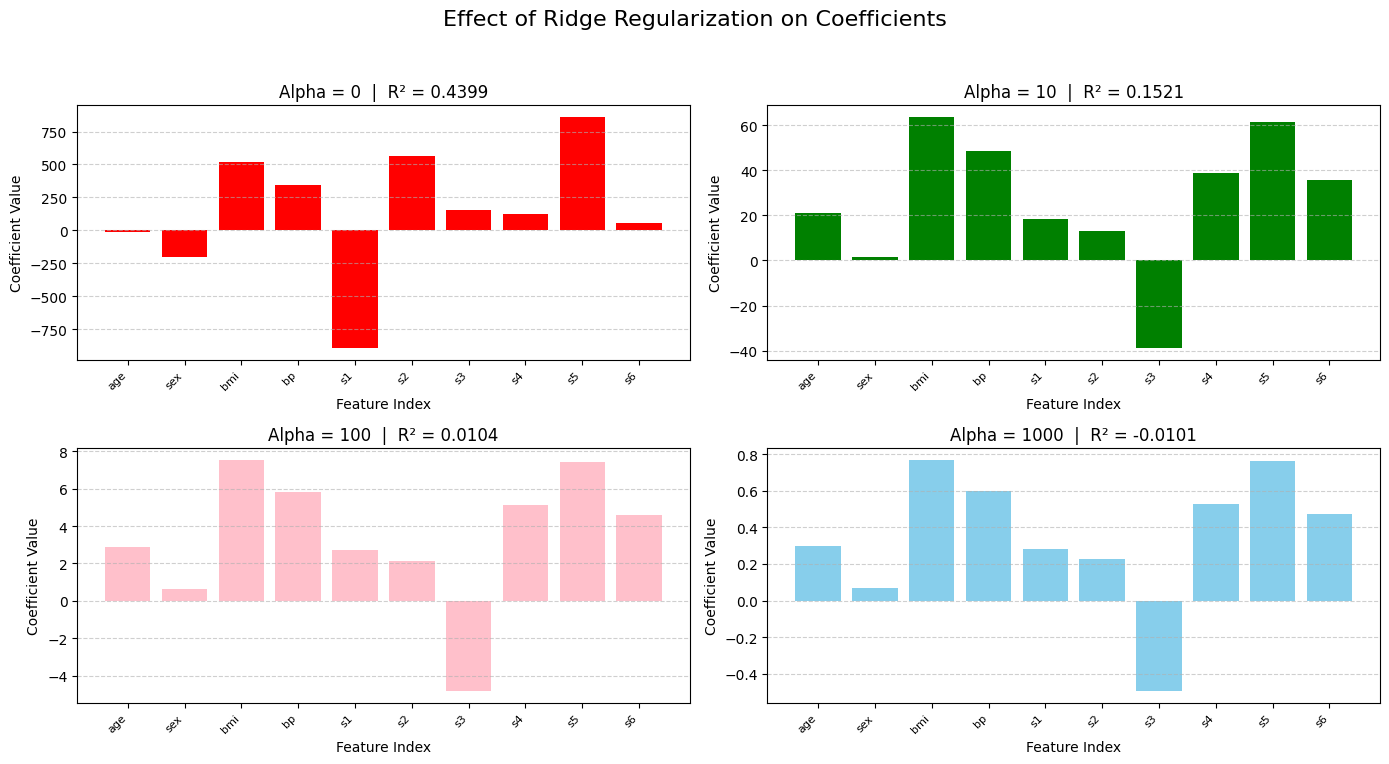

In [3]:
# Plotting: 2 rows x 2 cols
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("Effect of Ridge Regularization on Coefficients", fontsize=16)

# Flatten axes for easy indexing
axes_flat = axes.flatten()

for idx, ax in enumerate(axes_flat):
    # bar plot of coefficients for this alpha
    ax.bar(np.arange(len(coefs[idx])), coefs[idx], color=colors[idx])
    ax.set_title(f"Alpha = {alphas[idx]}  |  R² = {r2_scores[idx]:.4f}", fontsize=12)
    ax.set_xlabel("Feature Index", fontsize=10)
    ax.set_ylabel("Coefficient Value", fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    # set feature names as x-ticks (optional: change to indices if labels crowd)
    ax.set_xticks(np.arange(len(data.feature_names)))
    ax.set_xticklabels(data.feature_names, rotation=45, ha='right', fontsize=8)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## **<font color="green">2. Higher coefficients are affected more.</font>**
- The higher value of coefficient will decrease fast than the lower value.

In [4]:
# ================================================
# Ridge Regression: Coefficient Paths Visualization
# ================================================
from sklearn.datasets import load_diabetes
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ============ Load Data ============
data = load_diabetes()
X_train, X_test, y_train, y_test = train_test_split(
    data.data, data.target, test_size=0.2, random_state=2
)

# ============ Define Alphas ============
alphas = [0, 0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000]

# ============ Compute Coefficients ============
coefs = []
for alpha in alphas:
    reg = Ridge(alpha=alpha)
    reg.fit(X_train, y_train)
    coefs.append(reg.coef_.tolist())

# Convert to DataFrame
input_array = np.array(coefs)
coef_df = pd.DataFrame(input_array, columns=data.feature_names)
coef_df['alpha'] = alphas
coef_df.set_index('alpha')

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
alpha,,,,,,,,,,
0.0000,-9.158653,-205.454322,516.693745,340.619999,-895.552002,561.220679,153.893110,126.731397,861.127002,52.421122
0.0001,-9.116119,-205.329219,516.889664,340.549436,-883.423872,551.559582,148.587063,125.353015,856.485935,52.468916
0.0010,-8.761487,-204.313404,518.380608,339.967926,-787.700510,475.282181,106.795253,114.629265,819.745723,52.873349
0.0100,-6.399507,-198.662945,522.056516,336.340595,-383.717571,152.670882,-66.053243,75.608209,659.875219,55.829221
0.1000,6.643733,-172.237474,485.529585,314.675846,-72.940209,-80.588688,-174.463527,83.614710,484.365316,73.585091
1.0000,42.242528,-57.304483,282.172125,198.059395,14.363734,-22.551079,-136.929684,102.023069,260.104294,98.552692
10.0000,21.174024,1.659837,63.659826,48.492858,18.421510,12.875466,-38.915435,38.842475,61.612302,35.505383
100.0000,2.858980,0.629453,7.540605,5.849949,2.710879,2.142135,-4.834047,5.108223,7.448451,4.576129
1000.0000,0.295726,0.069290,0.769004,0.597824,0.282900,0.225936,-0.495607,0.527031,0.761496,0.471029


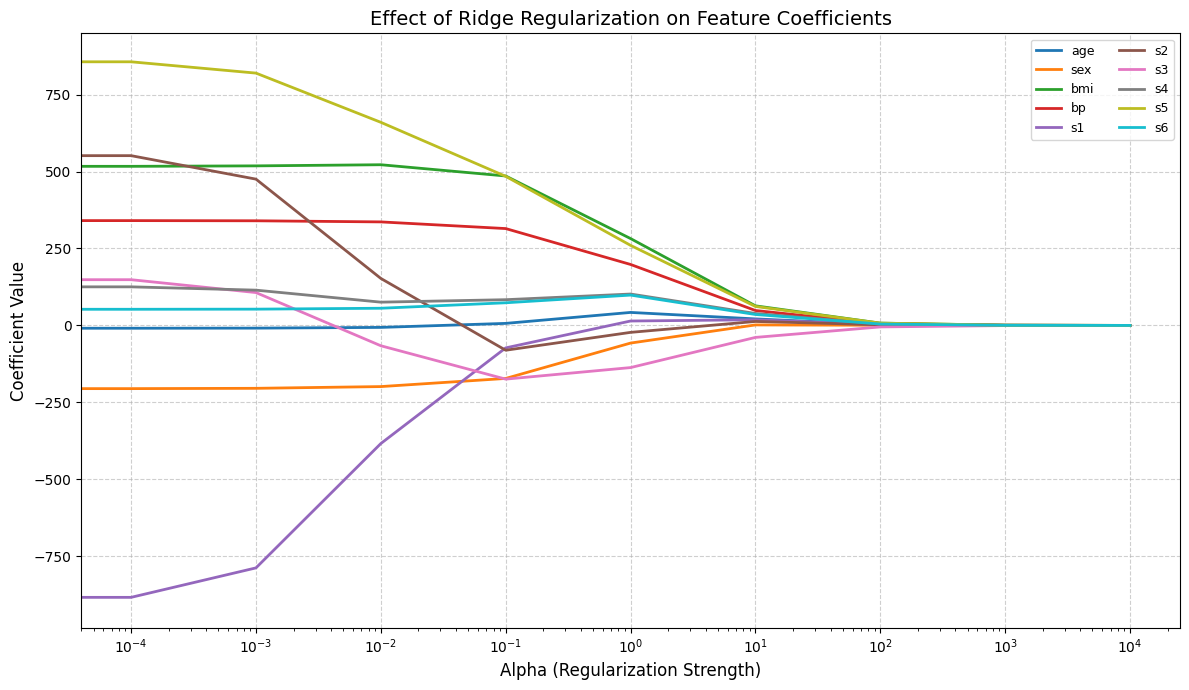

In [5]:
# ================================================
# Ridge Regression: Coefficient Paths Visualization
# ================================================
from sklearn.datasets import load_diabetes
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ============ Load Data ============
data = load_diabetes()
X_train, X_test, y_train, y_test = train_test_split(
    data.data, data.target, test_size=0.2, random_state=2
)

# ============ Define Alphas ============
alphas = [0, 0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000]

# ============ Compute Coefficients ============
coefs = []
for alpha in alphas:
    reg = Ridge(alpha=alpha)
    reg.fit(X_train, y_train)
    coefs.append(reg.coef_.tolist())

# Convert to DataFrame
input_array = np.array(coefs)
coef_df = pd.DataFrame(input_array, columns=data.feature_names)
coef_df['alpha'] = alphas
coef_df.set_index('alpha', inplace=True)

# ============ Plotting ============
plt.figure(figsize=(12, 7))
for feature in data.feature_names:
    plt.plot(coef_df.index, coef_df[feature], label=feature, linewidth=2)

plt.xscale('log')  # Log scale for better alpha visualization
plt.xlabel("Alpha (Regularization Strength)", fontsize=12)
plt.ylabel("Coefficient Value", fontsize=12)
plt.title("Effect of Ridge Regularization on Feature Coefficients", fontsize=14)
plt.legend(loc='best', fontsize=9, ncol=2)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


## **<font color="green">3. Bias Variance Trade-off</font>**
- ![](../img/Bias-Variance-Tradeoff-in-Ridge-Regression.webp)
- ![](../img/under-over-fitting.png)

### ***<font color="blue">Degree 6</font>***

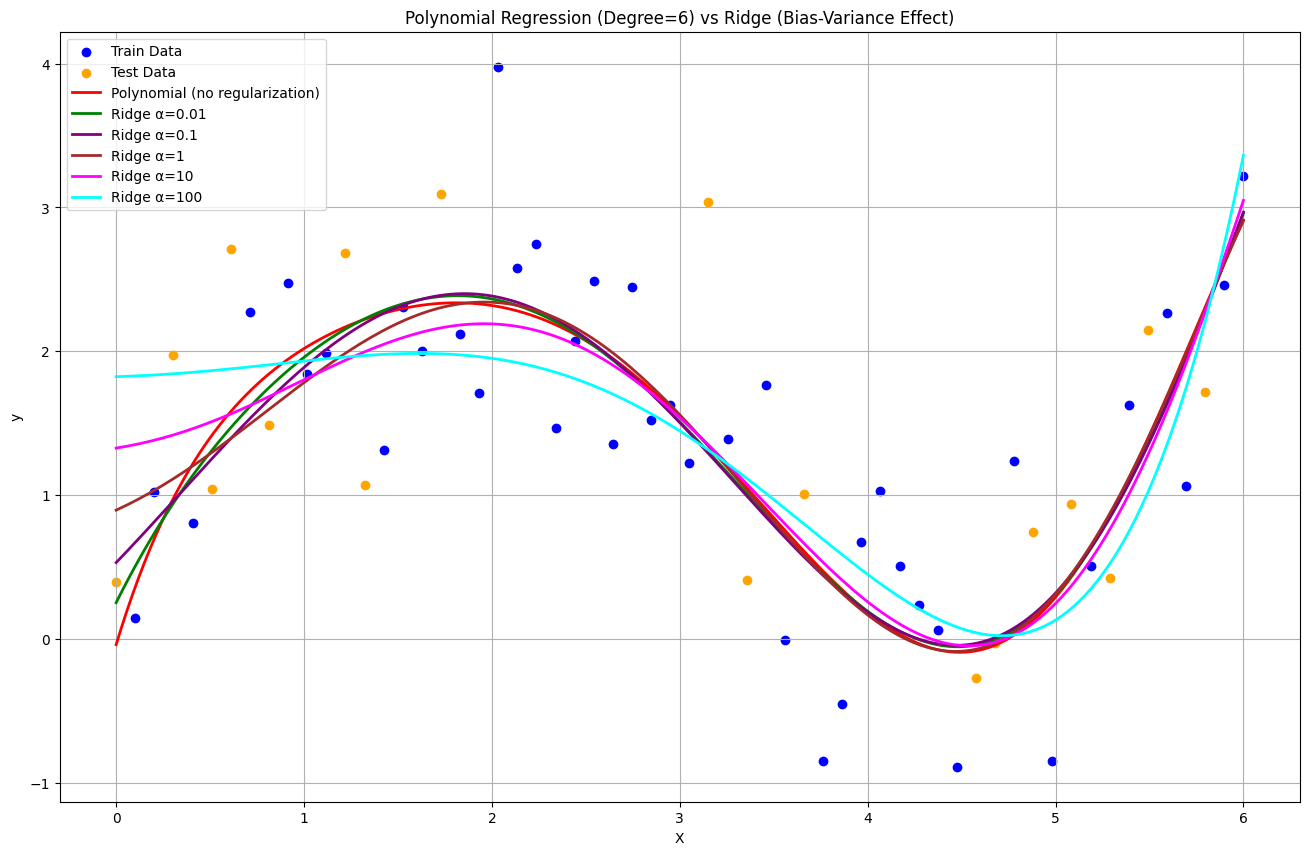

No Regularization         | Train MSE: 0.4069 | Test MSE: 0.5621
Ridge α=0.01              | Train MSE: 0.4090 | Test MSE: 0.5675
Ridge α=0.1               | Train MSE: 0.4132 | Test MSE: 0.5717
Ridge α=1                 | Train MSE: 0.4243 | Test MSE: 0.5610
Ridge α=10                | Train MSE: 0.4540 | Test MSE: 0.5776
Ridge α=100               | Train MSE: 0.5599 | Test MSE: 0.6841


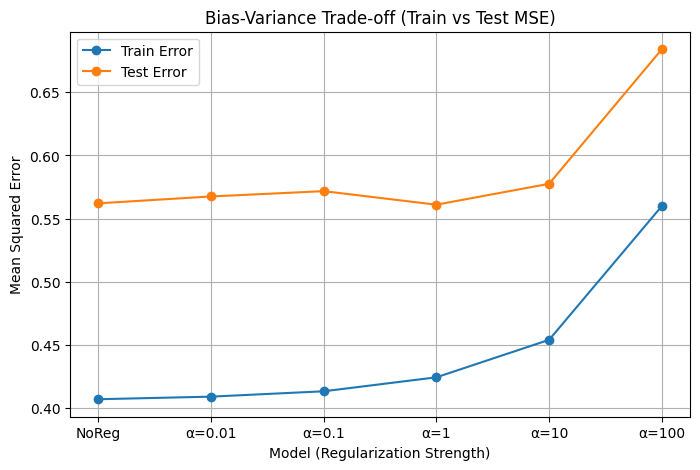

In [6]:
# polynomial_ridge_bias_variance.py
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# ==================================
# Step 1: Create synthetic dataset
# ==================================
np.random.seed(42)
X = np.linspace(0, 6, 60)[:, np.newaxis]
y = 2 * np.sin(X) + 0.5 * X + np.random.randn(60, 1) * 0.8

# Split train/test (to study bias-variance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# ==================================
# Step 2: Polynomial regression (degree=6)
# ==================================
degree = 6
poly_reg = make_pipeline(PolynomialFeatures(degree), LinearRegression())
poly_reg.fit(X_train, y_train)

# ==================================
# Step 3: Ridge regression for different alphas
# ==================================
alphas = [0.01, 0.1, 1, 10, 100]
ridge_models = [make_pipeline(PolynomialFeatures(degree), Ridge(alpha=a)) for a in alphas]
for model in ridge_models:
    model.fit(X_train, y_train)

# ==================================
# Step 4: Visualize model fits
# ==================================
X_plot = np.linspace(0, 6, 200)[:, np.newaxis]
plt.figure(figsize=(16, 10))
plt.scatter(X_train, y_train, color='blue', label='Train Data')
plt.scatter(X_test, y_test, color='orange', label='Test Data')

# Plot Polynomial Regression
plt.plot(X_plot, poly_reg.predict(X_plot), color='red', linewidth=2, label='Polynomial (no regularization)')

# Plot Ridge Regression
colors = ['green', 'purple', 'brown', 'magenta', 'cyan']
for alpha, model, color in zip(alphas, ridge_models, colors):
    y_pred = model.predict(X_plot)
    plt.plot(X_plot, y_pred, color=color, linewidth=2, label=f'Ridge α={alpha}')

plt.title(f'Polynomial Regression (Degree={degree}) vs Ridge (Bias-Variance Effect)')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

# ==================================
# Step 5: Compute train/test MSE
# ==================================
models = [('No Regularization', poly_reg)] + [(f'Ridge α={a}', m) for a, m in zip(alphas, ridge_models)]

train_errors = []
test_errors = []

for name, model in models:
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    train_errors.append(train_mse)
    test_errors.append(test_mse)
    print(f"{name:<25} | Train MSE: {train_mse:.4f} | Test MSE: {test_mse:.4f}")

# ==================================
# Step 6: Plot bias-variance trade-off
# ==================================
plt.figure(figsize=(8, 5))
plt.plot(['NoReg'] + [f'α={a}' for a in alphas], train_errors, marker='o', label='Train Error')
plt.plot(['NoReg'] + [f'α={a}' for a in alphas], test_errors, marker='o', label='Test Error')
plt.title('Bias-Variance Trade-off (Train vs Test MSE)')
plt.xlabel('Model (Regularization Strength)')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True)
plt.show()


### ***<font color="blue">Degree 16</font>***

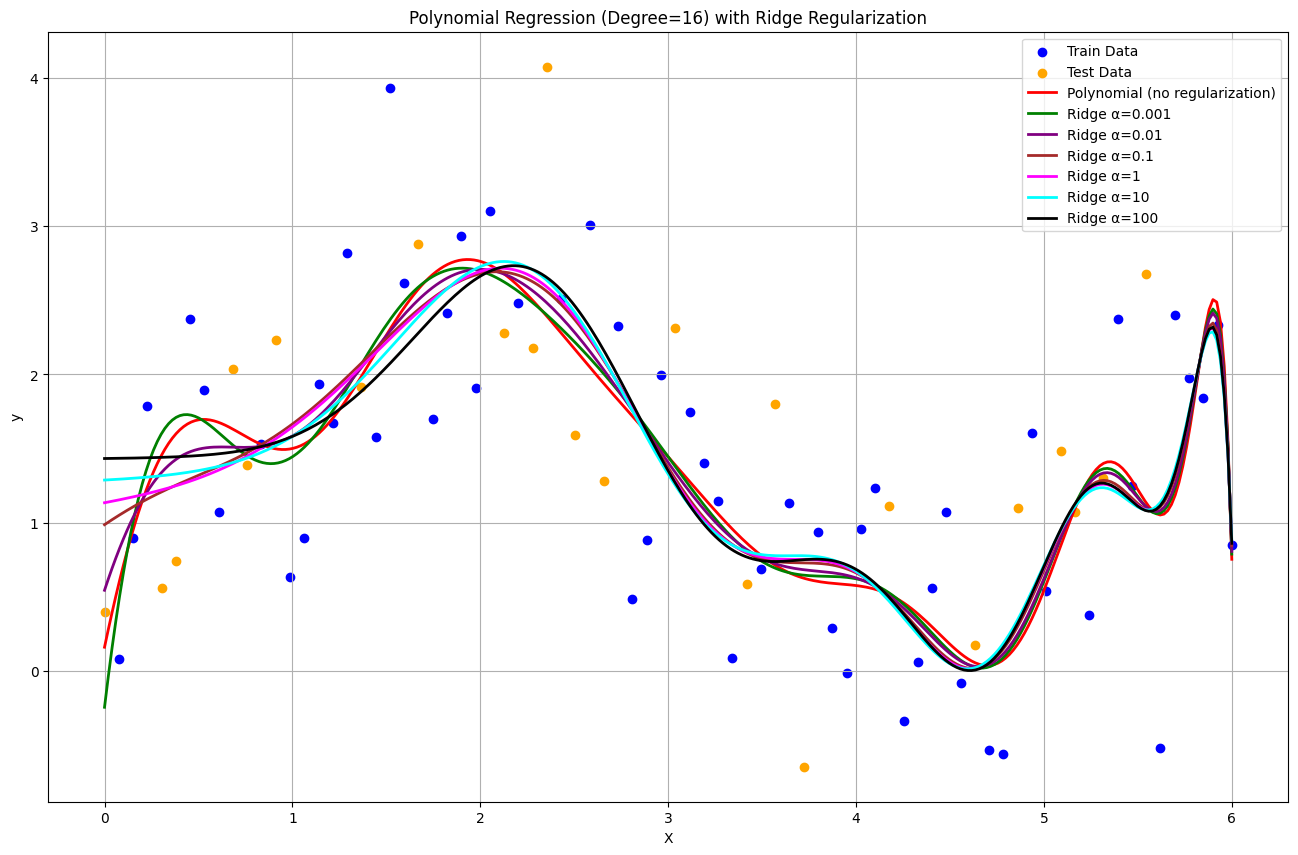

No Regularization         | Train MSE: 0.4384 | Test MSE: 0.5845
Ridge α=0.001             | Train MSE: 0.4206 | Test MSE: 0.6335
Ridge α=0.01              | Train MSE: 0.4425 | Test MSE: 0.5732
Ridge α=0.1               | Train MSE: 0.4608 | Test MSE: 0.5805
Ridge α=1                 | Train MSE: 0.4660 | Test MSE: 0.5940
Ridge α=10                | Train MSE: 0.4707 | Test MSE: 0.6199
Ridge α=100               | Train MSE: 0.4779 | Test MSE: 0.6491


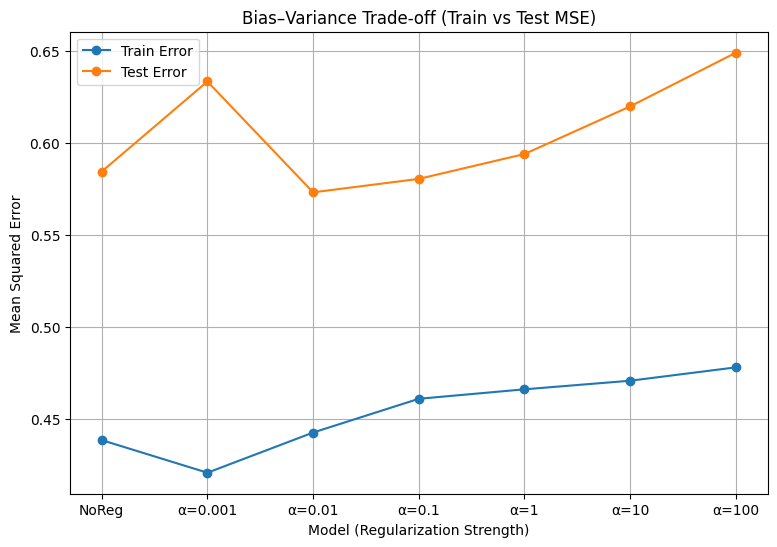

In [7]:
# polynomial_ridge_bias_variance_deg16.py
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# ==================================
# Step 1: Create synthetic dataset
# ==================================
np.random.seed(42)
X = np.linspace(0, 6, 80)[:, np.newaxis]
y = 2 * np.sin(X) + 0.5 * X + np.random.randn(80, 1) * 0.8

# Split data into train/test (for bias–variance analysis)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# ==================================
# Step 2: Define high-degree polynomial regression (degree=16)
# ==================================
degree = 16
poly_reg = make_pipeline(PolynomialFeatures(degree), LinearRegression())
poly_reg.fit(X_train, y_train)

# ==================================
# Step 3: Ridge regression with different alphas
# ==================================
alphas = [0.001, 0.01, 0.1, 1, 10, 100]
ridge_models = [make_pipeline(PolynomialFeatures(degree), Ridge(alpha=a)) for a in alphas]
for model in ridge_models:
    model.fit(X_train, y_train)

# ==================================
# Step 4: Visualize fits
# ==================================
X_plot = np.linspace(0, 6, 300)[:, np.newaxis]

plt.figure(figsize=(16, 10))
plt.scatter(X_train, y_train, color='blue', label='Train Data')
plt.scatter(X_test, y_test, color='orange', label='Test Data')

# Plot plain polynomial regression
plt.plot(X_plot, poly_reg.predict(X_plot), color='red', linewidth=2, label='Polynomial (no regularization)')

# Plot ridge models
colors = ['green', 'purple', 'brown', 'magenta', 'cyan', 'black']
for alpha, model, color in zip(alphas, ridge_models, colors):
    y_pred = model.predict(X_plot)
    plt.plot(X_plot, y_pred, color=color, linewidth=2, label=f'Ridge α={alpha}')

plt.title(f'Polynomial Regression (Degree={degree}) with Ridge Regularization')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

# ==================================
# Step 5: Compute train/test MSE
# ==================================
models = [('No Regularization', poly_reg)] + [(f'Ridge α={a}', m) for a, m in zip(alphas, ridge_models)]

train_errors = []
test_errors = []

for name, model in models:
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    train_errors.append(train_mse)
    test_errors.append(test_mse)
    print(f"{name:<25} | Train MSE: {train_mse:.4f} | Test MSE: {test_mse:.4f}")

# ==================================
# Step 6: Plot Bias–Variance Trade-off
# ==================================
plt.figure(figsize=(9, 6))
plt.plot(['NoReg'] + [f'α={a}' for a in alphas], train_errors, marker='o', label='Train Error')
plt.plot(['NoReg'] + [f'α={a}' for a in alphas], test_errors, marker='o', label='Test Error')
plt.title('Bias–Variance Trade-off (Train vs Test MSE)')
plt.xlabel('Model (Regularization Strength)')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True)
plt.show()


### ***<font color="blue">Effect of Bias and Variance Plots</font>***

X_train.shape = (80, 1), X_test.shape = (20, 1)
y_train.shape = (80,), y_test.shape = (20,)

Best alpha (min avg expected MSE) = 7.878788, loss = 1.384981


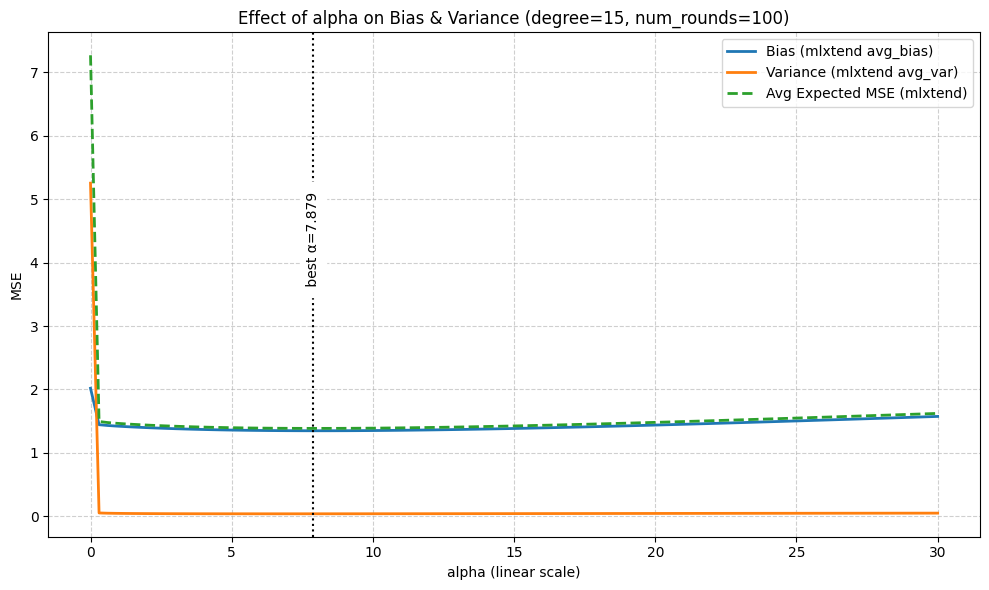


Structured Summary Table (selected α values):


,alpha,Avg_Expected_Loss,Bias,Variance
0,0.00000,7.271956,2.017980,5.253976
1,4.24242,1.402684,1.364793,0.037891
2,8.48485,1.385230,1.347646,0.037584
3,12.72727,1.404241,1.365073,0.039168
4,17.27273,1.447297,1.405876,0.041421


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Ridge
from mlxtend.evaluate import bias_variance_decomp

# ---------------------------
# Optional: quiet noisy numeric warnings
# ---------------------------
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message="Ill-conditioned matrix")
warnings.filterwarnings("ignore", message="Singular matrix")

# ---------------------------
# Data: user-provided style
# ---------------------------
np.random.seed(2)
m = 100
X = 5 * np.random.rand(m, 1) - 2            # uniform in [-2, 3]
y = 0.7 * X**2 - 2 * X + 3 + np.random.randn(m, 1)  # shape (m,1)

# reshape/flatten for sklearn (mlxtend expects 1d y)
X = X.reshape(-1, 1)
y = y.ravel()

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2
)

print(f"X_train.shape = {X_train.shape}, X_test.shape = {X_test.shape}")
print(f"y_train.shape = {y_train.shape}, y_test.shape = {y_test.shape}")

# ---------------------------
# Sweep alphas and run bias-variance decomposition
# ---------------------------
# Use a pipeline: PolynomialFeatures -> StandardScaler -> Ridge
degree = 15
alphas = np.linspace(0.0, 30.0, 100)   # as you requested: 0 -> 30 (100 points)

num_rounds = 100   # number of resampling rounds used by mlxtend (increase for smoother estimates)
random_seed = 123

loss_list = []
bias_list = []
var_list = []

for alpha in alphas:
    # When alpha == 0 we still use Ridge(alpha=0.0) which behaves like ordinary least squares.
    estimator = make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=False),
        StandardScaler(),
        Ridge(alpha=float(alpha), solver='svd', max_iter=2000)
    )

    # mlxtend will internally resample training sets num_rounds times and compute averages on the test set
    avg_expected_loss, avg_bias, avg_var = bias_variance_decomp(
        estimator,
        X_train, y_train,
        X_test, y_test,
        loss='mse',
        num_rounds=num_rounds,
        random_seed=random_seed
    )

    loss_list.append(avg_expected_loss)
    bias_list.append(avg_bias)
    var_list.append(avg_var)

    # optional progress printing
    # print(f"alpha={alpha:.4f}  loss={avg_expected_loss:.4f}  bias={avg_bias:.4f}  var={avg_var:.4f}")

loss_arr = np.array(loss_list)
bias_arr = np.array(bias_list)
var_arr = np.array(var_list)

# Best alpha according to avg expected loss
best_idx = np.argmin(loss_arr)
best_alpha = alphas[best_idx]
print(f"\nBest alpha (min avg expected MSE) = {best_alpha:.6f}, loss = {loss_arr[best_idx]:.6f}")

# ---------------------------
# Plot results
# ---------------------------
plt.figure(figsize=(10, 6))
plt.plot(alphas, bias_arr, label='Bias (mlxtend avg_bias)', linewidth=2)
plt.plot(alphas, var_arr, label='Variance (mlxtend avg_var)', linewidth=2)
plt.plot(alphas, loss_arr, label='Avg Expected MSE (mlxtend)', linewidth=2, linestyle='--')

plt.axvline(best_alpha, color='k', linestyle=':', linewidth=1.5)
ypos = loss_arr.max() * 0.6
plt.text(best_alpha, ypos, f' best α={best_alpha:.3f} ', rotation=90, va='center',
         ha='center', backgroundcolor='white')

plt.xlabel('alpha (linear scale)')
plt.ylabel('MSE')
plt.title(f'Effect of alpha on Bias & Variance (degree={degree}, num_rounds={num_rounds})')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# ---------------------------
# Print a structured summary table for selected alphas
# ---------------------------
print("\nStructured Summary Table (selected α values):")

# Select ~8 evenly spaced alpha indices
sample_idx = np.round(np.linspace(0, len(alphas) - 1, 8)).astype(int)

# Create a DataFrame for better readability
summary_df = pd.DataFrame({
    "alpha": [alphas[i] for i in sample_idx],
    "Avg_Expected_Loss": [loss_arr[i] for i in sample_idx],
    "Bias": [bias_arr[i] for i in sample_idx],
    "Variance": [var_arr[i] for i in sample_idx]
})

# Round for readability
summary_df = summary_df.round({
    "alpha": 5,
    "Avg_Expected_Loss": 6,
    "Bias": 6,
    "Variance": 6
})

# Print as a formatted table
summary_df.head()


## **<font color="green">4. Effect of Regularization on Loss Function</font>**

Coefficient: 27.82809103252014
Intercept: -2.29474455867698


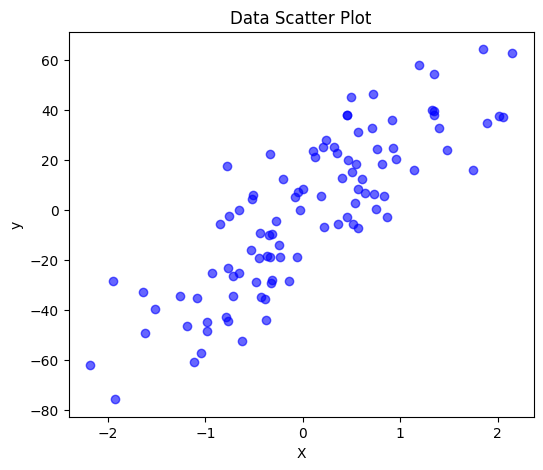

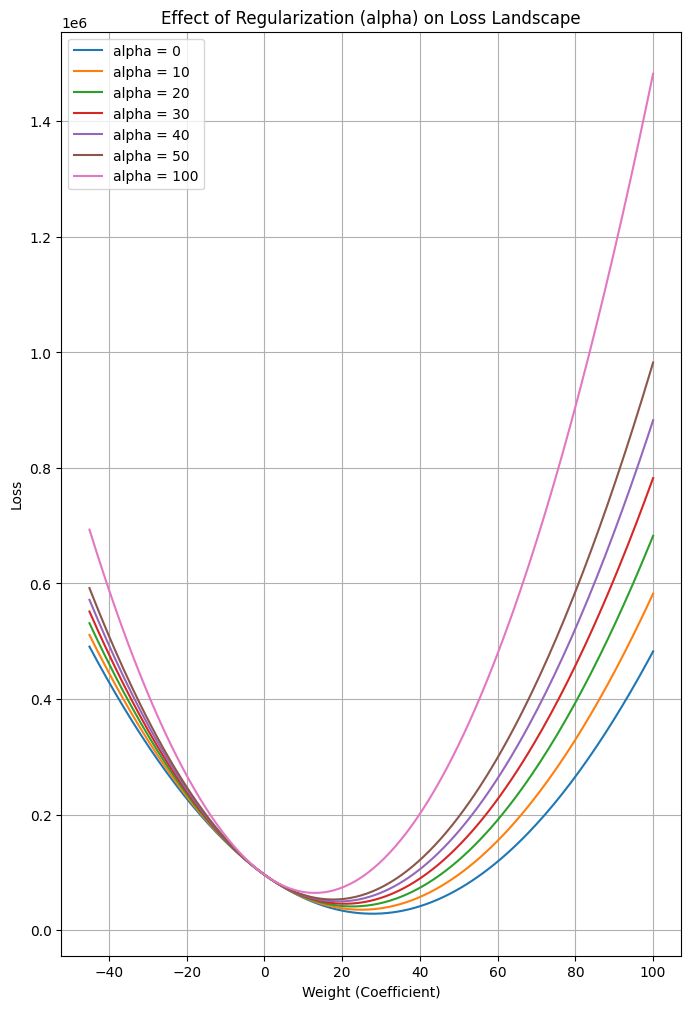

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression

# -----------------------------
# Generate synthetic regression data
# -----------------------------
X, y = make_regression(
    n_samples=100, 
    n_features=1, 
    n_informative=1, 
    n_targets=1, 
    noise=20, 
    random_state=13
)

# -----------------------------
# Fit Linear Regression
# -----------------------------
reg = LinearRegression()
reg.fit(X, y)

print("Coefficient:", reg.coef_[0])
print("Intercept:", reg.intercept_)

# -----------------------------
# Plot raw data
# -----------------------------
plt.figure(figsize=(6, 5))
plt.scatter(X, y, color='blue', alpha=0.6)
plt.title("Data Scatter Plot")
plt.xlabel("X")
plt.ylabel("y")
plt.show()

# -----------------------------
# Extract parameters
# -----------------------------
weights = reg.coef_[0]
bias = reg.intercept_

# -----------------------------
# Define loss with regularization (like Ridge)
# -----------------------------
def cal_loss(w, alpha):
    """
    Loss = Sum((y - (w*X + b))^2) + alpha * w^2
    """
    y_pred = w * X.ravel() + bias
    return np.sum((y - y_pred) ** 2) + alpha * (w ** 2)

# -----------------------------
# Range of possible weight values
# -----------------------------
m = np.linspace(-45, 100, 200)

# -----------------------------
# Plot loss vs coefficient for various alphas
# -----------------------------
plt.figure(figsize=(8, 12))
for alpha in [0, 10, 20, 30, 40, 50, 100]:
    losses = [cal_loss(w, alpha) for w in m]
    plt.plot(m, losses, label=f'alpha = {alpha}')

plt.legend()
plt.xlabel('Weight (Coefficient)')
plt.ylabel('Loss')
plt.title('Effect of Regularization (alpha) on Loss Landscape')
plt.grid(True)
plt.show()


## **<font color="green">5. Why called Ridge?</font>**
- ![Ridge Regression Loss Landscape](../img/ridge.png)